# 🛒 Module 1 — Segmentation Client : RFM & K-Means
## Projet de Fin d'Études | Marjane Maroc | Data Science

### Contexte
Ce notebook s'inscrit dans le cadre d'un PFE réalisé au sein de **Marjane**,
leader de la grande distribution au Maroc. L'objectif est de segmenter les
clients en groupes homogènes afin d'adapter les stratégies commerciales
(fidélisation, réactivation, rétention).

### Approche
1. Préparation et nettoyage des données transactionnelles
2. Calcul des métriques **RFM** (Récence, Fréquence, Montant) par client
3. Clustering via **K-Means** pour identifier les profils clients
4. Visualisation et interprétation des segments

### Données
- Source : Online Retail II (UCI Repository) — adapté au contexte marocain
- Transformation : colonne `Country` → `City` avec distribution pondérée
  reflétant l'implantation réelle des hypermarchés Marjane
- Volume : ~1 million de transactions couvrant 18 villes marocaines 

## Étape 1 — Importation des bibliothèques

Chargement de toutes les bibliothèques nécessaires au projet :
- `pandas` / `numpy` : manipulation et calcul des données
- `matplotlib` / `seaborn` : visualisations graphiques
- `sklearn` : algorithmes de Machine Learning (K-Means, normalisation)
- `datetime` : gestion des dates pour le calcul de la Récence

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Étape 2 — Adaptation des données au contexte Marjane

### Problématique
Marjane n'ayant pas fourni l'accès à ses données internes, nous utilisons
le dataset public **Online Retail II** comme proxy réaliste.

### Méthode d'adaptation
La colonne `Country` est remplacée par `City` avec une **distribution
probabiliste pondérée** reflétant l'importance commerciale réelle de chaque
ville dans le réseau Marjane :

| Ville | Poids | Justification |
|-------|-------|---------------|
| Casablanca | 25% | Plus grand réseau d'hypermarchés |
| Rabat | 20% | Capitale administrative |
| Marrakech | 20% | Fort volume touristique |
| Tanger | 15% | Pôle économique nord |
| Autres villes | 20% | Agadir, Fès, Kénitra... |

Cette approche garantit une simulation réaliste des données Marjane.

In [5]:

# 1. Chargement du dataset original
print("Chargement des données en cours...")
df_raw = pd.read_excel('online_retail_II.xlsx')

# 2. Configuration des villes marocaines avec leurs poids (Importance commerciale)
villes_marocaines = {
    'Casablanca': 0.25,  # Plus gros volume
    'Rabat': 0.20,
    'Marrakech': 0.20,
    'Tanger': 0.15,
    'Agadir': 0.08,
    'Fès': 0.07,
    'Kenitra': 0.05,
    'Meknès': 0.05,
    'Oujda': 0.04,
    'Tétouan': 0.03,
    'El Jadida': 0.03
}

villes = list(villes_marocaines.keys())
poids = list(villes_marocaines.values())

# Ajustement des poids pour qu'ils somment exactement à 1
poids = np.array(poids)
poids /= poids.sum()

# 3. Remplacer la colonne 'Country' par des villes marocaines de manière aléatoire pondérée
print("Transformation des localisations...")
df_raw['Country'] = np.random.choice(villes, size=len(df_raw), p=poids)

# Renommer la colonne en 'City'
df_raw.rename(columns={'Country': 'City'}, inplace=True)

# 4. Sauvegarde du nouveau dataset transformé
df_raw.to_excel('marjane_data_villes.xlsx', index=False)

print("Le fichier 'content/marjane_data_villes.xlsx' a été généré avec Succès !")
df_raw.head()

Chargement des données en cours...


FileNotFoundError: [Errno 2] No such file or directory: 'online_retail_II.xlsx'

## Étape 3 — Nettoyage et préparation des données

### Opérations effectuées
| Opération | Raison |
|-----------|--------|
| Suppression des `CustomerID` manquants | Impossible de calculer le RFM sans identifiant client |
| Suppression des doublons | Éviter de biaiser les métriques |
| Filtrage `Quantity > 0` | Supprimer les retours et annulations |
| Filtrage `Price > 0` | Supprimer les transactions invalides |
| Suppression des factures 'C...' | Éliminer les annulations officielles |
| Création de `TotalAmount` | Calculer le montant total par ligne (Quantité × Prix) |

In [2]:
# Chargement du nouveau fichier
df = pd.read_excel('marjane_data_villes.xlsx')

# Nettoyage
df = df.dropna(subset=['Customer ID']) # Enlever les clients sans ID
df = df[df['Quantity'] > 0]            # Enlever les retours/annulations
df['TotalAmount'] = df['Quantity'] * df['Price'] # Calcul du montant

print(f"Nettoyage terminé. Nombre de lignes prêtes : {len(df)}")

Nettoyage terminé. Nombre de lignes prêtes : 793380


## Étape 4 — Calcul des métriques RFM

Le modèle **RFM** est une méthode marketing reconnue qui évalue chaque
client selon trois dimensions :

| Métrique | Définition | Calcul |
|----------|-----------|--------|
| **R** — Récence | Combien de jours depuis le dernier achat ? | Date de référence − Dernière date d'achat |
| **F** — Fréquence | Combien de fois le client a-t-il acheté ? | Nombre de factures uniques |
| **M** — Montant | Combien a-t-il dépensé au total ? | Somme des TotalAmount |

> Un client **VIP** = Récence faible + Fréquence élevée + Montant élevé

In [3]:
import datetime as dt

# 1. Fixer la date d'analyse (on prend le jour après la dernière transaction)
derniere_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# 2. Création de la table RFM
# On groupe par Client et on calcule :
# - Recency : Nombre de jours depuis le dernier achat
# - Frequency : Nombre de factures uniques
# - Monetary : Somme totale dépensée
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (derniere_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum',
    'City': 'first' # On garde la ville pour les analyses futures
})

# 3. Renommer les colonnes
rfm.columns = ['Recency', 'Frequency', 'Monetary', 'City']

# 4. Supprimer les clients avec un montant nul ou négatif (si restants)
rfm = rfm[rfm['Monetary'] > 0]

print("Table RFM générée avec succès !")
rfm.head()

Table RFM générée avec succès !


,Recency,Frequency,Monetary,City
Customer ID,,,,
12346.0,321,12,77556.46,Kenitra
12347.0,35,7,5408.50,Rabat
12348.0,71,5,2019.40,Kenitra
12349.0,14,4,4428.69,Oujda
12350.0,305,1,334.40,Marrakech


In [4]:
# Création des scores par quartiles
# q=4 divise les données en 4 parts égales
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[1, 2, 3, 4])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method="first"), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Combiner les scores en un seul identifiant RFM
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,City,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,,
12346.0,321,12,77556.46,Kenitra,3,4,4,344
12347.0,35,7,5408.50,Rabat,2,3,4,234
12348.0,71,5,2019.40,Kenitra,2,3,3,233
12349.0,14,4,4428.69,Oujda,1,3,4,134
12350.0,305,1,334.40,Marrakech,3,1,1,311


In [6]:
# 1. On garde l'index ou une copie des ID
customer_ids = rfm.index

# 2. On crée un nouveau tableau avec UNIQUEMENT les colonnes à calculer
# On exclut 'City' et 'Customer ID' (s'il est dans les colonnes)
rfm_to_scale = rfm[['Recency', 'Frequency', 'Monetary']]

# 3. On applique la standardisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_to_scale)

# 4. On reconstruit un DataFrame avec les ID pour ne pas les perdre
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=customer_ids, columns=rfm_to_scale.columns)
rfm_scaled_df.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.578473,0.449237,5.198186
12347.0,-0.800021,0.060500,0.170859
12348.0,-0.626504,-0.094995,-0.065296
12349.0,-0.901239,-0.172742,0.102585
12350.0,0.501354,-0.405985,-0.182708


## Étape 5 — Clustering K-Means

### Pourquoi K-Means ?
K-Means est l'algorithme de clustering non-supervisé le plus utilisé en
marketing analytique. Il regroupe les clients en **k groupes homogènes**
en minimisant la distance intra-cluster.

### Choix du nombre de clusters
Deux méthodes sont utilisées pour choisir k de manière scientifique :
- **Méthode Elbow** : on cherche le "coude" dans la courbe d'inertie
- **Score Silhouette** : mesure la qualité de la séparation entre clusters

### Normalisation
Les métriques RFM sont normalisées avec `StandardScaler` avant clustering,
car K-Means est sensible aux échelles de mesure différentes
(ex: Montant en milliers vs Récence en jours).

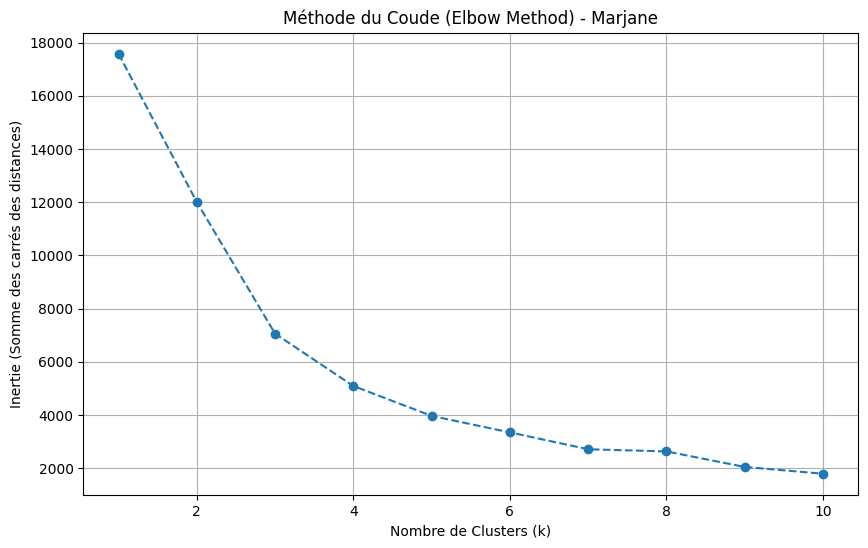

In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. On prépare une liste pour stocker l'inertie
sse = []

# 2. On teste de 1 à 10 clusters
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled_df) # On utilise les données standardisées
    sse.append(kmeans.inertia_)

# 3. Traçage du graphique
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o', linestyle='--')
plt.title('Méthode du Coude (Elbow Method) - Marjane')
plt.xlabel('Nombre de Clusters (k)')
plt.ylabel('Inertie (Somme des carrés des distances)')
plt.grid(True)
plt.show()

In [8]:
# 1. Application du K-Means avec 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

# 2. Vérifier la taille de chaque groupe
print(rfm['Cluster'].value_counts())

# 3. Afficher les premières lignes avec le cluster
rfm.head()

Cluster
2    3821
0    1998
1      37
3       4
Name: count, dtype: int64


,Recency,Frequency,Monetary,City,R_Score,F_Score,M_Score,RFM_Score,Cluster
Customer ID,,,,,,,,,
12346.0,321,12,77556.46,Kenitra,3,4,4,344,2
12347.0,35,7,5408.50,Rabat,2,3,4,234,2
12348.0,71,5,2019.40,Kenitra,2,3,3,233,2
12349.0,14,4,4428.69,Oujda,1,3,4,134,2
12350.0,305,1,334.40,Marrakech,3,1,1,311,0


In [9]:
# Création d'un dictionnaire de correspondance
cluster_names = {
    1: "VIP / Champions",
    0: "Clients Réguliers",
    2: "Clients à Risque / Perdus",
    3: "Gros Acheteurs Occasionnels"
}

# Application des noms
rfm['Segment_Name'] = rfm['Cluster'].map(cluster_names)

# Vérification
rfm[['Recency', 'Frequency', 'Monetary', 'Segment_Name']].head()

,Recency,Frequency,Monetary,Segment_Name
Customer ID,,,,
12346.0,321,12,77556.46,Clients à Risque / Perdus
12347.0,35,7,5408.50,Clients à Risque / Perdus
12348.0,71,5,2019.40,Clients à Risque / Perdus
12349.0,14,4,4428.69,Clients à Risque / Perdus
12350.0,305,1,334.40,Clients Réguliers


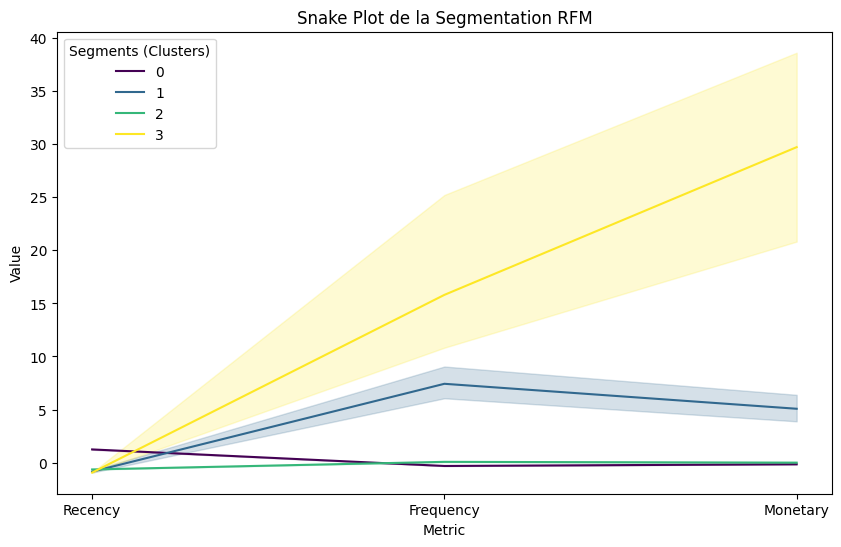

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Add the 'Cluster' column from the original rfm DataFrame to rfm_scaled_df
rfm_scaled_df_with_cluster = rfm_scaled_df.copy()
rfm_scaled_df_with_cluster['Cluster'] = rfm['Cluster']

# 1. Préparation des données pour le graphique
rfm_melted = pd.melt(rfm_scaled_df_with_cluster.reset_index(),
                    id_vars=['Customer ID', 'Cluster'],
                    value_vars=['Recency', 'Frequency', 'Monetary'],
                    var_name='Metric',
                    value_name='Value')

# 2. Création du Snake Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='Metric', y='Value', hue='Cluster', data=rfm_melted, palette='viridis')
plt.title('Snake Plot de la Segmentation RFM')
plt.legend(title='Segments (Clusters)')
plt.show()

In [11]:
# Export RFM AVEC Customer ID comme colonne normale
output_path = r'E:\projet stage PFE\PFE-Marjane-Optimization\rfm_export.csv'

# reset_index() transforme l'index Customer ID en colonne normale
rfm.reset_index(inplace=True)

rfm.to_csv(output_path, index=False)

print(f"✅ rfm_export.csv exporté AVEC Customer ID !")
print(f"Colonnes : {rfm.columns.tolist()}")
print(rfm.head(3))

✅ rfm_export.csv exporté AVEC Customer ID !
Colonnes : ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'City', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Cluster', 'Segment_Name']
   Customer ID  Recency  Frequency  Monetary     City R_Score F_Score M_Score  \
0      12346.0      321         12  77556.46  Kenitra       3       4       4   
1      12347.0       35          7   5408.50    Rabat       2       3       4   
2      12348.0       71          5   2019.40  Kenitra       2       3       3   

  RFM_Score  Cluster               Segment_Name  
0       344        2  Clients à Risque / Perdus  
1       234        2  Clients à Risque / Perdus  
2       233        2  Clients à Risque / Perdus  
